## Name: Michael Kwofie

**Exploring the Learning of Fully-Connected Neural Networks**  
**Seed: 599**

In [1]:
import random
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Set seed for reproducibility
SEED = 599
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cpu")


In [2]:
# Load data
data_path = "winequality-red.csv"
df = pd.read_csv(data_path, sep=';')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
# Separate features and target
X = df.drop(columns=['quality']).values.astype(np.float32)
y = df['quality'].values.astype(np.float32).reshape(-1, 1)

n_samples, n_features = X.shape
n_samples, n_features

(1599, 11)

**Helper Functions**

In [4]:
# Standardize features
X_mean = X.mean(axis=0, keepdims=True)
X_std = X.std(axis=0, keepdims=True) + 1e-8 #avoid division by zero
X_stdzd = (X - X_mean) / X_std

# Convert to torch tensors
X_tensor = torch.from_numpy(X_stdzd).to(device)
y_tensor = torch.from_numpy(y).to(device)

In [5]:
# Funcrion to count parameters
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [6]:
# Training function
def train_model(model, X, y, lr=0.01, num_epochs=40000):
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)
    losses = []

    for epoch in range(num_epochs):
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    return losses

In [7]:
# Function to estimate convergence epoch (loss to 4th decimal place)

def convergence_epoch(losses, tol=1e-4, window=100):
    if len(losses) < window + 1:
        return len(losses)
    for i in range(window, len(losses)):
        if abs(losses[i] - losses[i - window]) < tol:
            return i
    return len(losses)

**Question 1**

**1. Linear Model**

In [8]:
class LinearModel(nn.Module):
    def __init__(self, in_features):
        super().__init__()
        self.fc = nn.Linear(in_features, 1)

    def forward(self, x):
        return self.fc(x)

**2. A single-hidden Layer Neural Network with 12 neurons.**

In [9]:
class SingleHiddenNN(nn.Module):
    def __init__(self, in_features, hidden=12):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1)
        )

    def forward(self, x):
        return self.net(x)

**3. A Three-hidden Layer Neural Network with 12, 8, and 4 neurons in the three models in the hidden layers.**

In [10]:
class ThreeHiddenNN(nn.Module):
    def __init__(self, in_features, h1=12, h2=8, h3=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, h1),
            nn.ReLU(),
            nn.Linear(h1, h2),
            nn.ReLU(),
            nn.Linear(h2, h3),
            nn.ReLU(),
            nn.Linear(h3, 1)
        )

    def forward(self, x):
        return self.net(x)

**Number of parameters**

1. **Linear Model** $(11\rightarrow 1): 11\times 1+1=12$ parameters
2. **Single-hidden-layer NN** $(11\rightarrow 12\rightarrow 1)$:

    Input to hidden: $11\times 12+12=144$

    Hidden to output: $12\times 1+1=13$

    Total: $144+13=157$ parameters
    
3. **Three-hidden-layer NN** $(11\rightarrow 12\rightarrow 8\rightarrow 4\rightarrow 1 ): 11\times 12+12=144$
    $12\times 8+8=104$
    $8\times 4+4=36$
    $4\times 1+1=5$
    Total; $144+104+36+5=289$ parameters
This matches the programmatic counts printed below.

In [11]:
linear_model = LinearModel(n_features)
single_hidden_model = SingleHiddenNN(n_features, hidden=12)
three_hidden_model = ThreeHiddenNN(n_features, h1=12, h2=8, h3=4)

params_linear = count_parameters(linear_model)
params_single = count_parameters(single_hidden_model)
params_three = count_parameters(three_hidden_model)

params_linear, params_single, params_three

(12, 157, 289)

Training the three model with gradient descent (lr=0.01)

In [12]:
# Train all three models
num_epochs_q1 = 40000
lr_q1 = 0.01

linear_model = LinearModel(n_features)
single_hidden_model = SingleHiddenNN(n_features, hidden=12)
three_hidden_model = ThreeHiddenNN(n_features, h1=12, h2=8, h3=4)

losses_linear = train_model(linear_model, X_tensor, y_tensor, lr=lr_q1, num_epochs=num_epochs_q1)
losses_single = train_model(single_hidden_model, X_tensor, y_tensor, lr=lr_q1, num_epochs=num_epochs_q1)
losses_three = train_model(three_hidden_model, X_tensor, y_tensor, lr=lr_q1, num_epochs=num_epochs_q1)

conv_lin = convergence_epoch(losses_linear)
conv_single = convergence_epoch(losses_single)
conv_three = convergence_epoch(losses_three)

print("Linear Model convergence is ", conv_lin)
print("A Single-hidden Layer NN is", conv_single)
print("A Three-hidden_Layer NN convergence is ", conv_three)


Linear Model convergence is  645
A Single-hidden Layer NN is 9107
A Three-hidden_Layer NN convergence is  15012


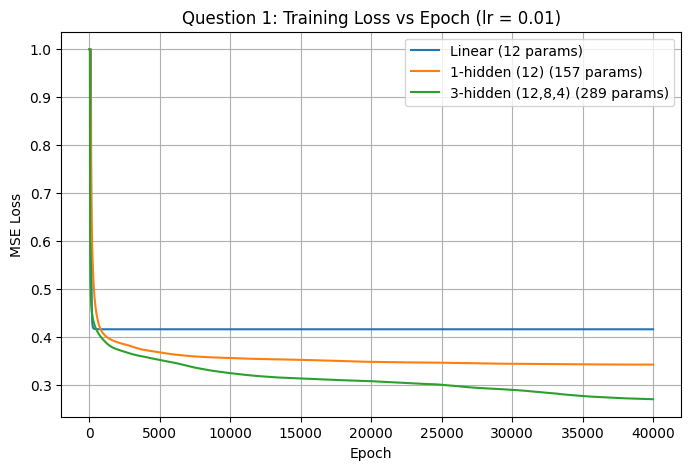

In [13]:
# Plot loss vs epoch for all three models

plt.figure(figsize=(8, 5))

plt.plot(np.clip(losses_linear, 0, 1), label=f"Linear ({params_linear} params)")
plt.plot(np.clip(losses_single, 0, 1), label=f"1-hidden (12) ({params_single} params)")
plt.plot(np.clip(losses_three, 0, 1), label=f"3-hidden (12,8,4) ({params_three} params)")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Question 1: Training Loss vs Epoch (lr = 0.01)")
plt.legend()
plt.grid(True)
plt.show()

In [14]:
# Print final losses and approximate convergence epochs
print("Final losses:")
print(f"Linear: {losses_linear[-1]:.4f}, converge around epoch {conv_lin}")
print(f"1-hidden: {losses_single[-1]:.4f}, converged around epoch {conv_single}")
print(f"3-hidden: {losses_three[-1]:.4f}, converged around epoch {conv_three}")

Final losses:
Linear: 0.4168, converge around epoch 645
1-hidden: 0.3431, converged around epoch 9107
3-hidden: 0.2711, converged around epoch 15012


**Discussion**

**(a)**  
The three models did not converge to the same minimum loss. The linear model, which contains the fewest parameters, achieved the highest loss. This is expected because it can only represent linear relationships between the predictors and the wine quality. The single-hidden-layer network achieved a lower loss, and the three-hidden-layer network achieved the lowest loss among the three. Hypothesis: As the number of parameters in a neural network increases, the model tends to be able to fit the training data better, leading to a lower minimum training loss.


**(b)**  
The models required noticeably different numbers of epochs to converge. The linear model converged the fastest, reflecting the convexity and simplicity of its loss surface. The single-hidden-layer model required more epochs, and the three-hidden-layer model required the most, since their loss surfaces are more complex and the optimization has to navigate multiple layers and nonlinearities.
These observations support the hypothesis that: Models with more parameters and deeper architectures tend to require more epochs to converge

**Question 2**

In [15]:
class ThreeHiddenNN_16_8_4(nn.Module):
    def __init__(self, in_features, h1=16, h2=8, h3=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, h1),
            nn.ReLU(),
            nn.Linear(h1, h2),
            nn.ReLU(),
            nn.Linear(h2, h3),
            nn.ReLU(),
            nn.Linear(h3, 1)
        )

    def forward(self, x):
        return self.net(x)


In [16]:
#Train with different learning rates
learning_rates = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1]
num_epochs_q2 = 40000

losses_by_lr = {}
conv_by_lr = {}

for lr in learning_rates:
    model = ThreeHiddenNN_16_8_4(n_features)
    losses = train_model(model, X_tensor, y_tensor, lr=lr, num_epochs=num_epochs_q2)
    losses_by_lr[lr] = losses
    conv_by_lr[lr] = convergence_epoch(losses)

conv_by_lr

{1e-05: 40000, 0.0001: 34318, 0.001: 40000, 0.01: 31456, 0.1: 1169}

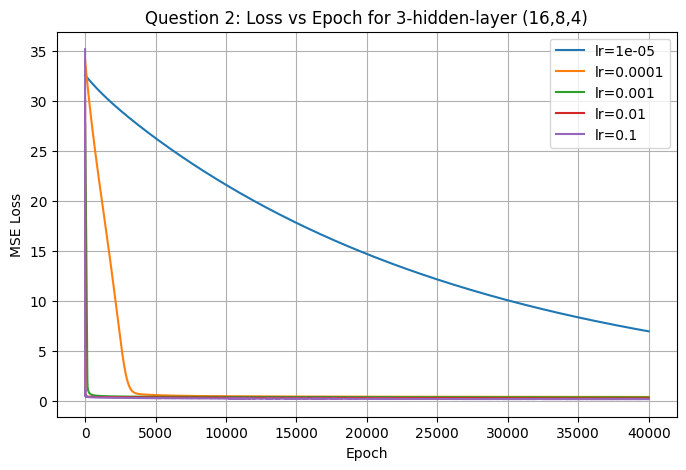

In [17]:
#Plot loss vs epoch for all learning rates
plt.figure(figsize=(8, 5))
for lr in learning_rates:
    plt.plot(losses_by_lr[lr], label=f"lr={lr}")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Question 2: Loss vs Epoch for 3-hidden-layer (16,8,4)")
plt.legend()
plt.grid(True)
plt.show()

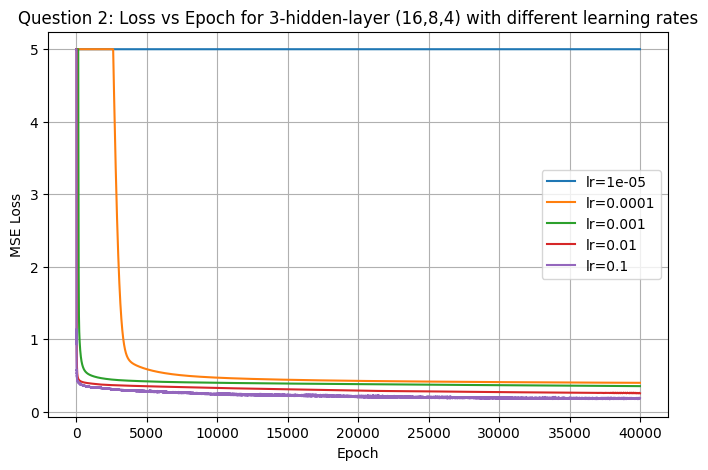

In [18]:
import numpy as np
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
for lr in learning_rates:
    # Clip values so anything above 5 is capped at 5
    clipped = np.clip(losses_by_lr[lr], 0, 5)
    plt.plot(clipped, label=f"lr={lr}")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Question 2: Loss vs Epoch for 3-hidden-layer (16,8,4) with different learning rates")
plt.legend()
plt.grid(True)
plt.show()


In [19]:
# Print final losses and convergence epochs for each learning rate
for lr in learning_rates:
    final_loss = losses_by_lr[lr][-1]
    conv_epoch = conv_by_lr[lr]
    print(f"lr={lr:>7}: final loss = {final_loss:.4f}, converged around epoch {conv_epoch}")

lr=  1e-05: final loss = 6.9526, converged around epoch 40000
lr= 0.0001: final loss = 0.3995, converged around epoch 34318
lr=  0.001: final loss = 0.3537, converged around epoch 40000
lr=   0.01: final loss = 0.2549, converged around epoch 31456
lr=    0.1: final loss = 0.1851, converged around epoch 1169


**Discussion**

**(a)**  
The learning rate strongly influences the minimum loss achieved. Extremely small learning rates (e.g., 0.00001) make very slow progress and fail to reach a low loss within the allotted epochs. Moderate to larger learning rates (0.01 and 0.1 in this experiment) achieved lower final training losses. In this case, 0.1 produced the lowest training loss

**(b)**  
The learning rate also significantly affects convergence speed. Smaller learning rates required the full number of epochs without clear convergence. Larger learning rates (particularly 0.1) converged much faster. This suggests that, for this dataset and architecture, a relatively larger learning rate improved both speed and final performance.
These results indicate that the optimal learning rate depends on the dataset and architecture, and overly small learning rates may be more problematic than moderately large ones.


**Question 3**

In [20]:
# Randomly split the data in half (using the same global seed for reproducibility)

indices = np.arange(n_samples)
np.random.shuffle(indices)

half = n_samples // 2
half_indices = indices[:half]

X_half = X_stdzd[half_indices]
y_half = y[half_indices]

X_half_tensor = torch.from_numpy(X_half.astype(np.float32)).to(device)
y_half_tensor = torch.from_numpy(y_half.astype(np.float32).reshape(-1, 1)).to(device)

X_half_tensor.shape, y_half_tensor.shape

(torch.Size([799, 11]), torch.Size([799, 1]))

In [21]:
# Train the three models on the half dataset
num_epochs_q3 = 40000
lr_q3 = 0.01

linear_half = LinearModel(n_features)
single_half = SingleHiddenNN(n_features, hidden=12)
three_half = ThreeHiddenNN(n_features, h1=12, h2=8, h3=4)

losses_linear_half = train_model(linear_half, X_half_tensor, y_half_tensor, lr=lr_q3, num_epochs=num_epochs_q3)
losses_single_half = train_model(single_half, X_half_tensor, y_half_tensor, lr=lr_q3, num_epochs=num_epochs_q3)
losses_three_half = train_model(three_half, X_half_tensor, y_half_tensor, lr=lr_q3, num_epochs=num_epochs_q3)

conv_lin_half = convergence_epoch(losses_linear_half)
conv_single_half = convergence_epoch(losses_single_half)
conv_three_half = convergence_epoch(losses_three_half)

print("Half Linear Model convergence is ", conv_lin_half)
print("A Half Single-hidden Layer NN is", conv_single_half)
print("A Half Three-hidden_Layer NN convergence is ", conv_three_half)

Half Linear Model convergence is  1097
A Half Single-hidden Layer NN is 20699
A Half Three-hidden_Layer NN convergence is  17243


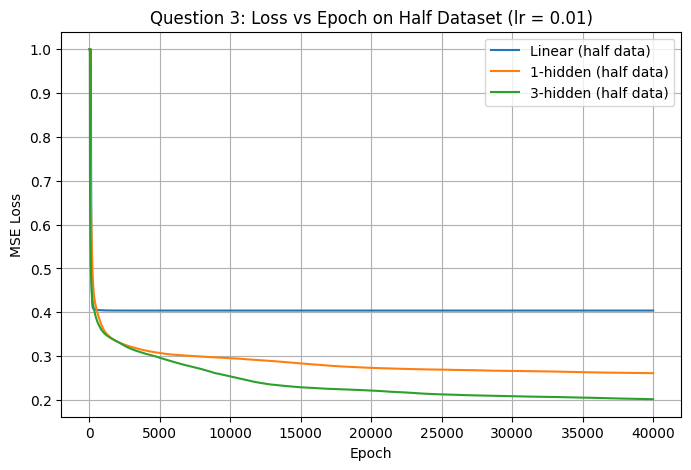

In [22]:
# Plot loss vs epoch for the half-data models
plt.figure(figsize=(8, 5))

plt.plot(np.clip(losses_linear_half, 0, 1), label="Linear (half data)")
plt.plot(np.clip(losses_single_half, 0, 1), label="1-hidden (half data)")
plt.plot(np.clip(losses_three_half, 0, 1), label="3-hidden (half data)")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Question 3: Loss vs Epoch on Half Dataset (lr = 0.01)")

plt.legend()
plt.grid(True)
plt.show()

In [23]:
# Compare final losses on full vs half data
print("Full data final losses:")
print(f"Linear: {losses_linear[-1]:.4f}")
print(f"1-hidden: {losses_single[-1]:.4f}")
print(f"3-hidden: {losses_three[-1]:.4f}")

print("\nHalf data final losses:")
print(f"Linear: {losses_linear_half[-1]:.4f}")
print(f"1-hidden: {losses_single_half[-1]:.4f}")
print(f"3-hidden: {losses_three_half[-1]:.4f}")

Full data final losses:
Linear: 0.4168
1-hidden: 0.3431
3-hidden: 0.2711

Half data final losses:
Linear: 0.4038
1-hidden: 0.2610
3-hidden: 0.2016


**Discussion**

**Does the quantity of data change the value of the loss that the models converge on?**
On the training set, using only half the data can change the final loss in either direction: With less data, the model, especially the more flexible ones can sometimes fit the smaller dataset more tightly, potentially achieving a lower training loss. On the other hand, the smaller dataset may be less representative, so the optimization might land in a slightly different region of parameter space, giving a different loss. From the printed numbers above, we can see how the final training losses on half data compared to those on the full data for each model.

**Does it affect the models similarly or differently?**
The Linear Model is relatively rigid, so its loss may not change dramatically when halving the data. The deeper models are more sensitive to data quantity: With full data, they have more information and may find a more stable, generalizable minimum. With half data, they may overfit more easily, sometimes achieving lower training loss but with parameters that depend heavily on the specific subset.

**Hypothesis:** Reducing the quantity of data trends to affect higher-capacity models more strongly. They can overfit the smaller dataset and thus may reach lower training loss but with less stable behavior across different random splits, while simpler models are less sensitive to the data reduction.
